In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
import numpy as np
import sympy as sp
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
import matplotlib.pyplot as plt
import time

In [3]:
# Construct an Input/Output CRN: 4 species, 9 reactions
S_R = np.array([[0, 0, 1, 1, 0, 1, 0, 0, 0], [0, 0, 1, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 1, 0, 0, 1, 0], [0, 1, 0, 0, 0, 0, 0, 0, 1]], dtype=np.int8)
S_P = np.array([[1, 0, 0, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0, 0, 0], [0, 1, 0, 0, 1, 0, 0, 0, 0]], dtype=np.int8)
mu = 1; theta = 1; eta = 0.01; k = 1; k_1 = 1; gamma_1 = 0.1; gamma_2 = 0.1; gamma_3 = 0.1; gamma_4 = 0.1
params = np.array([mu, theta, eta, k, k_1, gamma_1, gamma_2, gamma_3, gamma_4], dtype=np.float32)
I = np.array([[1, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.int8)
O = np.array([4], dtype=np.int8)
IOCRN = IOCRN_MassAction(S_R, S_P, params, I, O)

In [4]:
# Print the Input/Output CRN
species = ['X_1', 'X_2', 'X_3', 'X_4']
inputs = ['u']
IOCRN.print_reactions(species, inputs)

Inputs: ['u']
Species: ['X_1', 'X_2', 'X_3', 'X_4']
Output Species: ['X_4']
Reaction 1: 0 -> X_1 ; Rate Constant: 1.0u
Reaction 2: X_4 -> X_2 + X_4 ; Rate Constant: 1.0
Reaction 3: X_1 + X_2 -> 0 ; Rate Constant: 0.009999999776482582
Reaction 4: X_1 -> X_1 + X_3 ; Rate Constant: 1.0
Reaction 5: X_3 -> X_3 + X_4 ; Rate Constant: 1.0
Reaction 6: X_1 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 7: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 8: X_3 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 9: X_4 -> 0 ; Rate Constant: 0.10000000149011612


In [5]:
# Print the ODEs of the Input/Output CRN
params_sym = sp.symbols('mu, theta, eta, k, k_1, gamma_1, gamma_2, gamma_3, gamma_4')
species_sym = sp.symbols('x_1, x_2, x_3, x_4')
inputs_sym = [sp.symbols('u')]
IOCRN.print_ODEs(species_sym, params_sym, inputs_sym)

⎡-η⋅x₁⋅x₂ - γ₁⋅x₁ + μ⋅u ⎤
⎢                       ⎥
⎢-η⋅x₁⋅x₂ - γ₂⋅x₂ + θ⋅x₄⎥
⎢                       ⎥
⎢     -γ₃⋅x₃ + k⋅x₁     ⎥
⎢                       ⎥
⎣    -γ₄⋅x₄ + k₁⋅x₃     ⎦


Matrix([
[     -eta*x_1*x_2 - gamma_1*x_1 + mu*u],
[-eta*x_1*x_2 - gamma_2*x_2 + theta*x_4],
[                  -gamma_3*x_3 + k*x_1],
[                -gamma_4*x_4 + k_1*x_3]])

In [6]:
# Linearize
A, B = IOCRN.linearize_ODEs(species_sym, params_sym, inputs_sym)
sp.pprint(A)
sp.pprint(B)

⎡-η⋅x₂ - γ₁    -η⋅x₁      0    0 ⎤
⎢                                ⎥
⎢  -η⋅x₂     -η⋅x₁ - γ₂   0    θ ⎥
⎢                                ⎥
⎢    k           0       -γ₃   0 ⎥
⎢                                ⎥
⎣    0           0       k₁   -γ₄⎦
⎡μ⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦


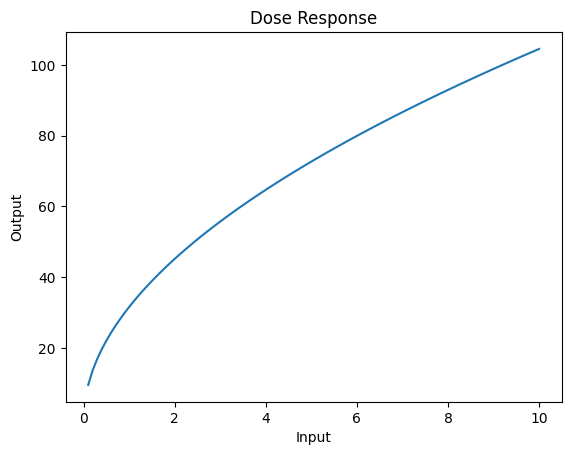

In [7]:
#  Dose Response
N_u = 100
u_array = np.linspace(0.1, 10, N_u, dtype=np.float32)
initial_guess = np.array([0.1, 0.1, 0.1, 0.1], dtype=np.float32)
y_array = IOCRN.dose_response(u_array, initial_guess, True)

Simulation Time: 0.17


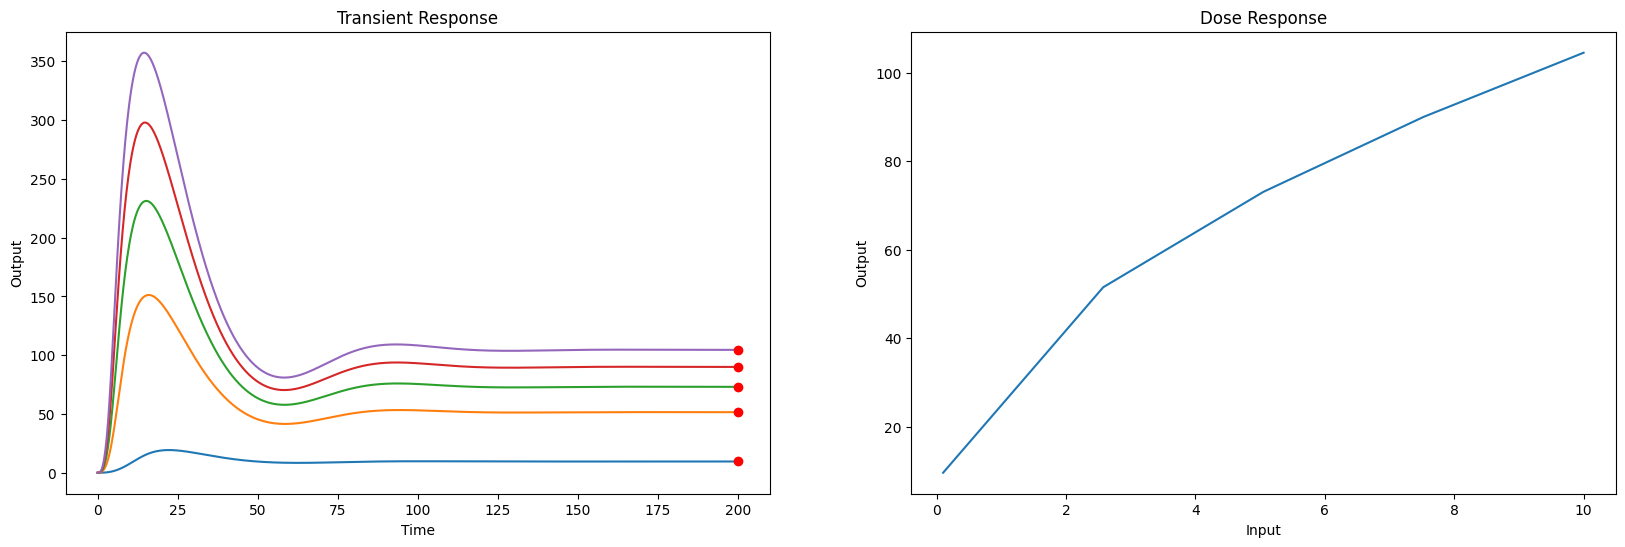

In [8]:
# Transient Response
N_u = 5
u_array = np.linspace(0.1, 10, N_u, dtype=np.float32)
initial_guess = np.array([0.1, 0.1, 0.1, 0.1], dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, 200, 1000, dtype=np.float32)

tic = time.time()
outputs_transient = IOCRN.transient_response(u_array, initial_condition, time_horizon)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

outputs_ss = IOCRN.dose_response(u_array, initial_guess, False)

plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
for i in range(len(outputs_transient)):
    plt.plot(time_horizon, outputs_transient[i])
    plt.plot(time_horizon[-1], outputs_ss[i], 'ro')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')
plt.subplot(1, 2, 2)
plt.plot(u_array, outputs_ss)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Dose Response')
plt.show()